In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

In [26]:
loaded_data = pd.read_csv("titanic.csv")

In [27]:
loaded_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [28]:
loaded_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [29]:
loaded_data.drop(columns=["PassengerId", "Ticket", "Cabin", "Name"], inplace=True)

In [30]:
sex_map = {"male": 0, "female": 1}

In [31]:
loaded_data = loaded_data.replace(sex_map)

C:\Users\aliis\AppData\Local\Temp\ipykernel_11180\3774690585.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loaded_data = loaded_data.replace(sex_map)


In [32]:
from sklearn.model_selection import train_test_split
X = loaded_data.drop(columns=["Survived"])
y = loaded_data["Survived"]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="most_frequent")

In [35]:
imputer.fit(X_train[['Embarked']])

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [36]:
X_train['Embarked'] = imputer.transform(X_train[['Embarked']]).ravel()
X_test['Embarked'] = imputer.transform(X_test[['Embarked']]).ravel()

In [37]:
groupby_age_median = X_train.groupby("Pclass")["Age"].median()
global_median = X_train["Age"].median()

# Train
X_train['Age'] = X_train['Age'].fillna(
    X_train['Pclass'].map(groupby_age_median)
)

# Test (safe fallback)
X_test['Age'] = X_test['Age'].fillna(
    X_test['Pclass'].map(groupby_age_median).fillna(global_median)
)

In [38]:
X_train['Age'] = X_train['Age'].astype(int)
X_test['Age'] = X_test['Age'].astype(int)

In [39]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 331 to 102
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    712 non-null    int64  
 1   Sex       712 non-null    int64  
 2   Age       712 non-null    int64  
 3   SibSp     712 non-null    int64  
 4   Parch     712 non-null    int64  
 5   Fare      712 non-null    float64
 6   Embarked  712 non-null    object 
dtypes: float64(1), int64(5), object(1)
memory usage: 44.5+ KB


In [40]:
X_train.groupby("Pclass")["Fare"].describe()

,count,mean,std,min,25%,50%,75%,max
Pclass,,,,,,,,
1,163.0,89.253911,84.309133,0.0,32.25,69.30,108.9000,512.3292
2,151.0,20.575938,12.812935,0.0,13.00,15.00,26.0000,73.5000
3,398.0,13.934860,12.344770,0.0,7.75,8.05,15.7417,69.5500


<Axes: xlabel='Pclass', ylabel='Fare'>

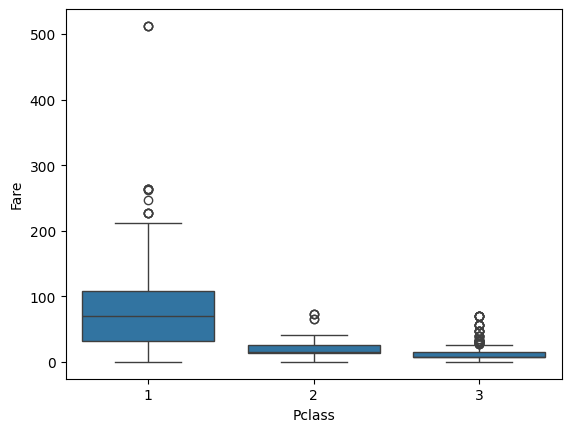

In [41]:
sns.boxplot(data=X_train, x="Pclass", y="Fare")

In [42]:
Q1_train = X_train.groupby("Pclass")["Fare"].quantile(0.25)
Q3_train = X_train.groupby("Pclass")["Fare"].quantile(0.75)
IQR_train = Q3_train - Q1_train

lower_bound_train = Q1_train - 1.5 * IQR_train
upper_bound_train = Q3_train + 1.5 * IQR_train

X_train['Fare'] = X_train['Fare'].clip(
    lower=X_train['Pclass'].map(lower_bound_train), 
    upper=X_train['Pclass'].map(upper_bound_train)
)

X_test['Fare'] = X_test['Fare'].clip(
    lower=X_test['Pclass'].map(lower_bound_train), 
    upper=X_test['Pclass'].map(upper_bound_train)
)

<Axes: xlabel='Pclass', ylabel='Fare'>

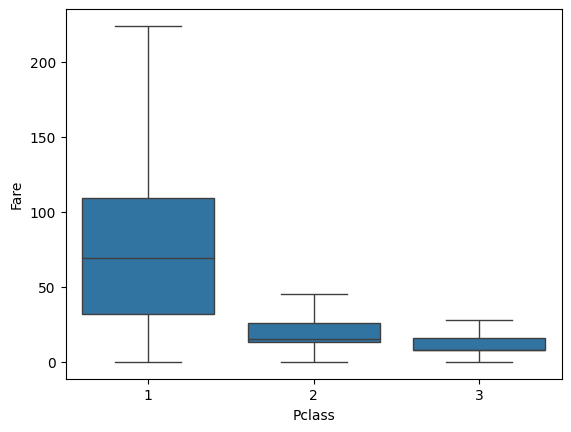

In [43]:
sns.boxplot(data=X_train, x="Pclass", y="Fare")

In [44]:
X_train.groupby("Pclass")["Fare"].describe()

,count,mean,std,min,25%,50%,75%,max
Pclass,,,,,,,,
1,163.0,82.513982,60.372781,0.0,32.25,69.30,108.9000,223.87500
2,151.0,19.761369,10.093458,0.0,13.00,15.00,26.0000,45.50000
3,398.0,12.196679,7.074996,0.0,7.75,8.05,15.7417,27.72925


In [45]:
mapping_embarked = {"S": 0, "C": 1, "Q": 2}
X_train['Embarked'] = X_train['Embarked'].map(mapping_embarked).astype(int)
X_test['Embarked'] = X_test['Embarked'].map(mapping_embarked).astype(int)

In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [47]:
scalled_features = ["Age", "Fare", "Pclass", "SibSp", "Parch", "Embarked", "Sex"]
scalled = scaler.fit(X_train[scalled_features])
X_train[scalled_features] = scalled.transform(X_train[scalled_features])
X_test[scalled_features] = scalled.transform(X_test[scalled_features])

In [48]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,-1.614136,-0.724310,1.216171,-0.470722,-0.479342,-0.033835,-0.548035
733,-0.400551,-0.724310,-0.455184,-0.470722,-0.479342,-0.408729,-0.548035
382,0.813034,-0.724310,0.228552,-0.470722,-0.479342,-0.531476,-0.548035
704,0.813034,-0.724310,-0.227272,0.379923,-0.479342,-0.533189,-0.548035
813,0.813034,1.380624,-1.746685,2.931860,2.048742,-0.052477,-0.548035
...,...,...,...,...,...,...,...
106,0.813034,1.380624,-0.607125,-0.470722,-0.479342,-0.538127,-0.548035
270,-1.614136,-0.724310,0.608405,-0.470722,-0.479342,0.026632,-0.548035
860,0.813034,-0.724310,0.912288,1.230569,-0.479342,-0.381923,-0.548035
435,-1.614136,1.380624,-1.138920,0.379923,2.048742,2.179247,-0.548035


In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


model = LogisticRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

[[91 14]
 [20 54]]
